In [21]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install pygal

Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install cairosvg

Note: you may need to restart the kernel to use updated packages.


In [24]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pygal
import plotly.express as px

In [25]:
df=pd.read_excel("employee.xlsx")
print(df)

  Employee ID  Employee Name Department  Total Working Days  Present Days  \
0        E001       Ali Khan         HR                  30            26   
1        E002     Sara Ahmed         IT                  30            27   
2        E003  Bilal Hussain    Finance                  30            25   
3        E004   Ayesha Malik      Admin                  30            29   
4        E005      Usman Ali  Marketing                  30            24   
5        E006      Hina Raza   Accounts                  30            26   
6        E007     Imran Shah         IT                  30            28   
7        E008    Nida Farooq         HR                  30            27   

   Absent Days  Leave Days  Late Arrivals  Total Hours Worked  
0            2           2              3               205.5  
1            1           2              1               210.8  
2            3           2              4               198.0  
3            0           1              2         

In [26]:
print(df.describe())

       Total Working Days  Present Days  Absent Days  Leave Days  \
count                 8.0      8.000000     8.000000    8.000000   
mean                 30.0     26.500000     1.875000    1.625000   
std                   0.0      1.603567     1.246423    0.517549   
min                  30.0     24.000000     0.000000    1.000000   
25%                  30.0     25.750000     1.000000    1.000000   
50%                  30.0     26.500000     2.000000    2.000000   
75%                  30.0     27.250000     2.250000    2.000000   
max                  30.0     29.000000     4.000000    2.000000   

       Late Arrivals  Total Hours Worked  
count       8.000000            8.000000  
mean        2.625000          207.362500  
std         1.407886           10.987647  
min         1.000000          190.400000  
25%         1.750000          201.075000  
50%         2.500000          207.400000  
75%         3.250000          212.500000  
max         5.000000          225.200000  


In [27]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee ID         8 non-null      object 
 1   Employee Name       8 non-null      object 
 2   Department          8 non-null      object 
 3   Total Working Days  8 non-null      int64  
 4   Present Days        8 non-null      int64  
 5   Absent Days         8 non-null      int64  
 6   Leave Days          8 non-null      int64  
 7   Late Arrivals       8 non-null      int64  
 8   Total Hours Worked  8 non-null      float64
dtypes: float64(1), int64(5), object(3)
memory usage: 708.0+ bytes
None


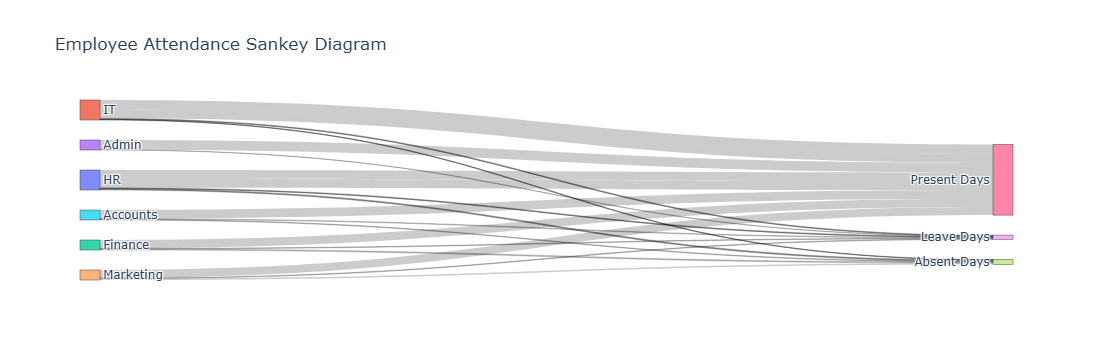

In [28]:
import pandas as pd
import plotly.graph_objects as go
# Labels (nodes)
labels = ["HR","IT","Finance","Admin","Marketing","Accounts",
          "Present Days","Absent Days","Leave Days"]

# Create flows
source = []
target = []
value = []

for i in range(len(df)):
    
    dept_index = labels.index(df["Department"][i])
    
    source.append(dept_index)
    target.append(labels.index("Present Days"))
    value.append(df["Present Days"][i])
    
    source.append(dept_index)
    target.append(labels.index("Absent Days"))
    value.append(df["Absent Days"][i])
    
    source.append(dept_index)
    target.append(labels.index("Leave Days"))
    value.append(df["Leave Days"][i])

# Create Sankey Diagram
fig = go.Figure(go.Sankey(
    node=dict(
        label=labels,
        pad=20,
        thickness=20
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
))
fig.update_layout(title_text="Employee Attendance Sankey Diagram", font_size=12)
fig.show()

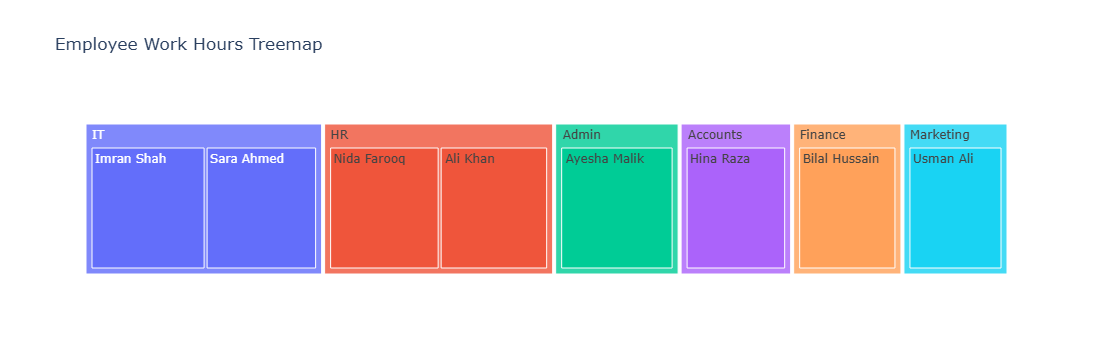

In [29]:
import pandas as pd
import plotly.express as px
# Create Treemap
fig = px.treemap(
    df,
    path=["Department","Employee Name"],  # hierarchy
    values="Total Hours Worked",          # size of boxes
    title="Employee Work Hours Treemap"
)
fig.show()

In [43]:
!pip install squarify

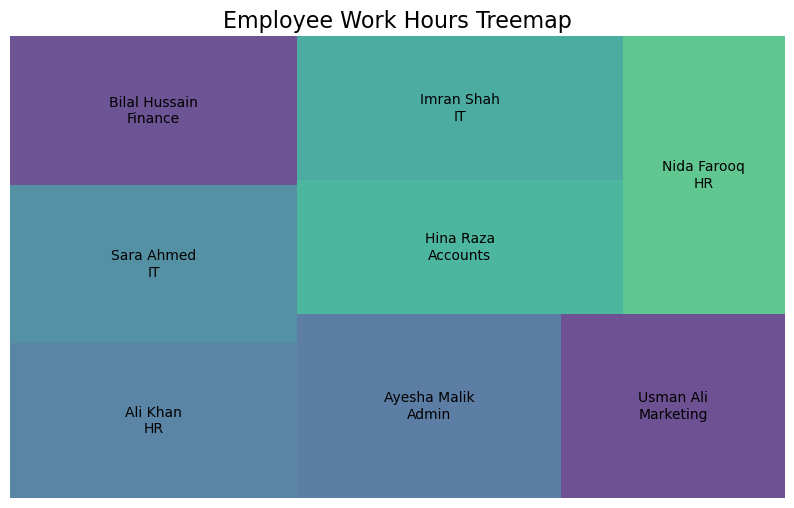

In [44]:
# Labels for treemap
import squarify
labels = df["Employee Name"] + "\n" + df["Department"]

# Plot treemap
plt.figure(figsize=(10,6))

squarify.plot(
    sizes=df["Total Hours Worked"],
    label=labels,
    alpha=0.8
)

plt.title("Employee Work Hours Treemap", fontsize=16)
plt.axis("off")

plt.show()